Original source: https://github.com/IBM/terramind/blob/main/notebooks/terramind_v1_small_sen1floods11.ipynb

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import torch
import gdown
import terratorch
import albumentations
import numpy as np
import lightning.pytorch as pl
import matplotlib.pyplot as plt
from pathlib import Path
from terratorch.datamodules import GenericNonGeoSegmentationDataModule
import warnings
warnings.filterwarnings("ignore")

## Sen1Floods11 Dataset

Lets start with analysing the dataset

In [ ]:
!pip install huggingface-hub
if not os.path.isdir("sen1floods11_v1.1"):
    !hf download blumenstiel/Sen1Floods11 sen1floods11_v1_1.tar.gz --repo-type dataset --local-dir ./
    !tar -xzf sen1floods11_v1_1.tar.gz

In [ ]:
!pip install gdown
import gdown
if not os.path.isdir("sen1floods11_v1.1"):
    gdown.download("https://drive.google.com/uc?id=1lRw3X7oFNq_WyzBO6uyUJijyTuYm23VS")
    !tar -xzf sen1floods11_v1.1.tar.gz

In [3]:
dataset_path = Path("sen1floods11_v1.1")
!ls "sen1floods11_v1.1/data"

CopernicusDEM   LabelHand       S1OtsuLabelHand
JRCWaterHand    S1GRDHand       S2L1CHand


TerraTorch provides generic data modules that work directly with PyTorch Lightning.

Sen1Floods11 is a multimodal dataset that provides Sentinel-2 L2A and Sentinel-1 GRD data. 
Therefore, we are using the `GenericMultiModalDataModule`. 
This module is similar to the `GenericNonGeoSegmentationDataModule`, which is used for standard segmentation tasks.
However, the data roots, `img_grep` are other settings are provided as dict to account for the multimodal inputs. You find all settings in the [documentation](https://terrastackai.github.io/terratorch/stable/generic_datamodules/).
In a Lightning config, the data module is defined with the `data` key.

In [4]:
datamodule = terratorch.datamodules.GenericMultiModalDataModule(
    task="segmentation",
    batch_size=8,
    num_workers=2,
    num_classes=2,

    # Define your input modalities. The names must match the keys in the following dicts.
    modalities=["S2L1C", 'DEM'],
    rgb_indices={
        "S2L1C": [3, 2, 1],
        'DEM': [0],
    },

    # Define data paths as dicts using the modality names as keys.
    train_data_root={
        "S2L1C": dataset_path / "data/S2L1CHand",
        "S1GRD": dataset_path / "data/S1GRDHand",
        "DEM": dataset_path / "data/CopernicusDEM",
    },
    train_label_data_root=dataset_path / "data/LabelHand",
    val_data_root={
        "S2L1C": dataset_path / "data/S2L1CHand",
        "S1GRD": dataset_path / "data/S1GRDHand",
        "DEM": dataset_path / "data/CopernicusDEM",
    },
    val_label_data_root=dataset_path / "data/LabelHand",
    test_data_root={
        "S2L1C": dataset_path / "data/S2L1CHand",
        "S1GRD": dataset_path / "data/S1GRDHand",
        "DEM": dataset_path / "data/CopernicusDEM",
    },
    test_label_data_root=dataset_path / "data/LabelHand",

    # Define split files because all samples are saved in the same folder.
    train_split=dataset_path / "splits/flood_train_data.txt",
    val_split=dataset_path / "splits/flood_valid_data.txt",
    test_split=dataset_path / "splits/flood_test_data.txt",
    
    # Define suffix, again using dicts.
    image_grep={
        "S2L1C": "*_S2Hand.tif",
        "S1GRD": "*_S1Hand.tif",
        "DEM": "*_DEM.tif",
    },
    label_grep="*_LabelHand.tif",
    
    # With TerraTorch, you can select a subset of the dataset bands as model inputs by providing dataset_bands (all bands in the data) and output_bands (selected bands). This setting is optional for all modalities and needs to be provided as dicts.
    # Here is an example for with S-1 GRD. You could change the output to ["VV"] to only train on the first band. Note that means and stds must be aligned with the output_bands (equal length of values). 
    dataset_bands={
        "S1GRD": ["VV", "VH"]
    },
    output_bands={
        "S1GRD": ["VV", "VH"]
    },

    # Define standardization values. We use the pre-training values here and providing the additional modalities is not a problem, which makes it simple to experiment with different modality combinations. Alternatively, use the dataset statistics that you can generate using `terratorch compute_statistics -c config.yaml` (requires concat_bands: true for this multimodal datamodule).
    means={
      "S2L1C": [2357.089, 2137.385, 2018.788, 2082.986, 2295.651, 2854.537, 3122.849, 3040.560, 3306.481, 1473.847, 506.070, 2472.825, 1838.929],
      "S2L2A": [1390.458, 1503.317, 1718.197, 1853.910, 2199.100, 2779.975, 2987.011, 3083.234, 3132.220, 3162.988, 2424.884, 1857.648],
      "S1GRD": [-12.599, -20.293],
      "S1RTC": [-10.93, -17.329],
      "RGB": [87.271, 80.931, 66.667],
      "DEM": [670.665]
    },
    stds={
      "S2L1C": [1624.683, 1675.806, 1557.708, 1833.702, 1823.738, 1733.977, 1732.131, 1679.732, 1727.26, 1024.687, 442.165, 1331.411, 1160.419],
      "S2L2A": [2106.761, 2141.107, 2038.973, 2134.138, 2085.321, 1889.926, 1820.257, 1871.918, 1753.829, 1797.379, 1434.261, 1334.311],
      "S1GRD": [5.195, 5.890],
      "S1RTC": [4.391, 4.459],
      "RGB": [58.767, 47.663, 42.631],
      "DEM": [951.272],
    },
    
        # albumentations supports shared transformations and can handle multimodal inputs. 
    train_transform=[
        albumentations.D4(), # Random flips and rotation
        # albumentations.RandomCrop(224, 224),
        albumentations.pytorch.transforms.ToTensorV2(),
    ],
    val_transform=None,  # Using ToTensorV2() by default if not provided
    test_transform=None,
    
    no_label_replace=-1,  # Replace NaN labels. defaults to -1 which is ignored in the loss and metrics.
    no_data_replace=0,  # Replace NaN data
    check_stackability=False, # Set to True if you are uncertain if all samples have the same input shape
)

# Setup train and val datasets
datamodule.setup("fit")

2026-07-24 16:09:52,138 - INFO - Train dataset: 252
2026-07-24 16:09:52,140 - INFO - Val dataset: 89


In [5]:
# checking datasets validation split size
val_dataset = datamodule.val_dataset
len(val_dataset)

89

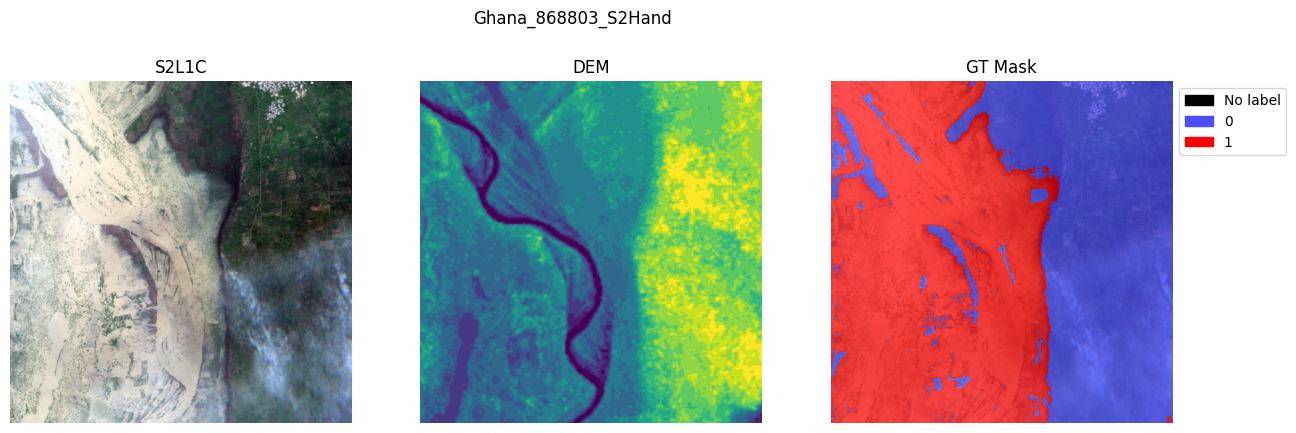

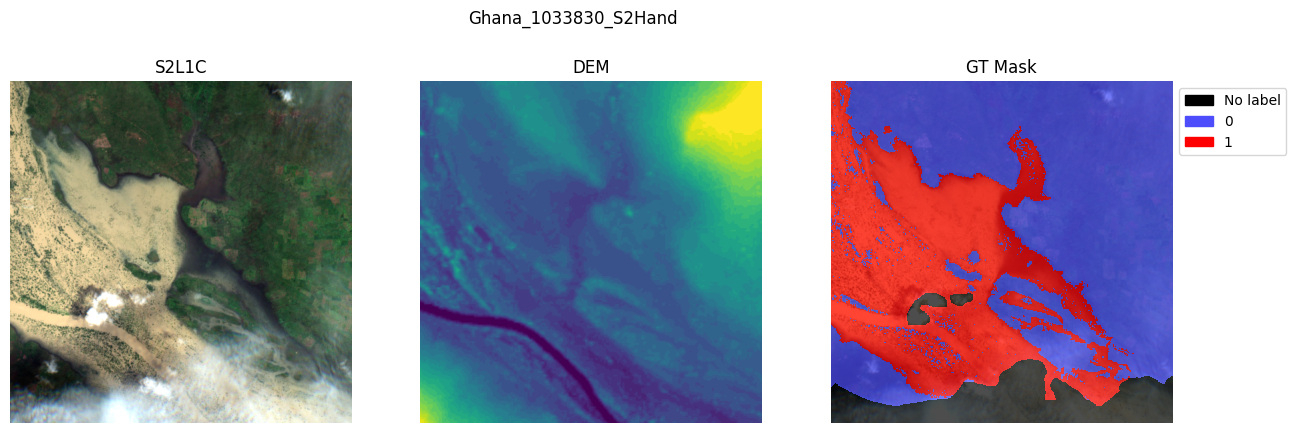

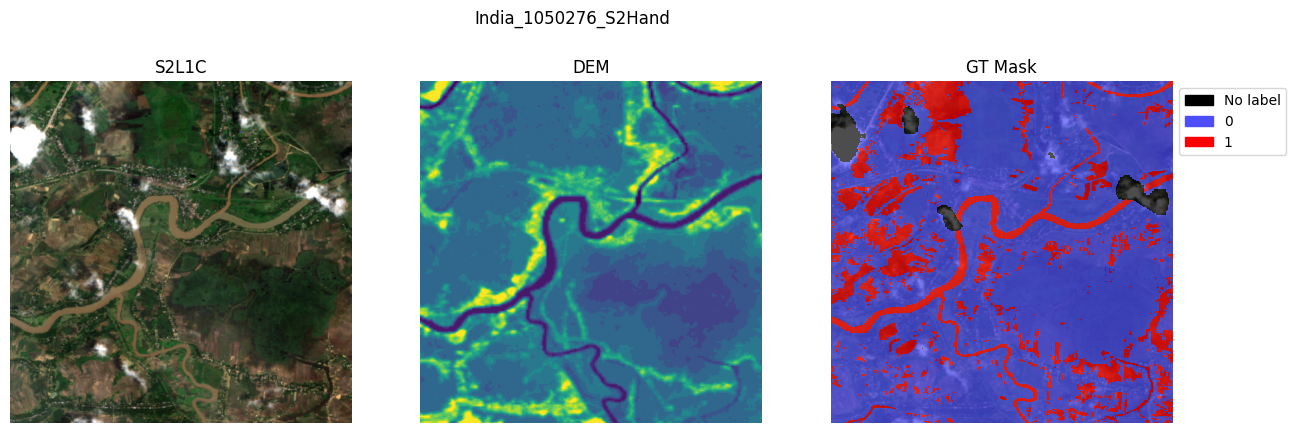

In [6]:
# The GenericMultiModalDataModule has an integrated plotting function with min/max scaling:
val_dataset.plot(val_dataset[2])
val_dataset.plot(val_dataset[8])
val_dataset.plot(val_dataset[11])
plt.show()

In [7]:
# checking datasets testing split size
datamodule.setup("test")
test_dataset = datamodule.test_dataset
len(test_dataset)

2026-07-24 16:09:52,641 - INFO - Test dataset: 90


90

# TerraTorch model registry

TerraTorch includes its own backbone registry with many EO FMs. It also includes meta registries for all model components that include other sources like timm image models or SMP decoders.

In [8]:
from terratorch.registry import BACKBONE_REGISTRY, TERRATORCH_BACKBONE_REGISTRY, TERRATORCH_DECODER_REGISTRY

In [9]:
# Print all TerraMind v1 backbones.  
[backbone   
 for backbone in TERRATORCH_BACKBONE_REGISTRY
 if 'terramind_v1' in backbone]
# TiM models are using the Thinking-in-Modalities approach, see our paper for details.

['terramind_v1_base',
 'terramind_v1_base_tim',
 'terramind_v1_large',
 'terramind_v1_large_tim',
 'terramind_v1_tiny',
 'terramind_v1_tiny_tim',
 'terramind_v1_small',
 'terramind_v1_small_tim',
 'terramind_v1_tokenizer_s2l2a',
 'terramind_v1_tokenizer_s1rtc',
 'terramind_v1_tokenizer_s1grd',
 'terramind_v1_tokenizer_dem',
 'terramind_v1_tokenizer_lulc',
 'terramind_v1_tokenizer_ndvi']

In [10]:
# Available decoders. We use the UNetDecoder in this example.
list(TERRATORCH_DECODER_REGISTRY)

['ASPPModule',
 'ASPPHead',
 'ASPPSegmentationHead',
 'ASPPRegressionHead',
 'FCNDecoder',
 'IdentityDecoder',
 'LinearDecoder',
 'MLPDecoder',
 'SatMAEHead',
 'UNetDecoder',
 'UperNetDecoder']

In [11]:
# Use the backbone registry to load a PyTorch model for a custom pipeline. The pre-trained weights are automatically downloaded with pretrained=True.
model = BACKBONE_REGISTRY.build(
    "terramind_v1_small",
    modalities=["S2L1C", "DEM"],
    pretrained=True,
)

# You find more information about the settings in the TerraMind docs: https://terrastackai.github.io/terratorch/stable/guide/terramind/

2026-07-24 16:09:53,140 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-small/resolve/main/TerraMind_v1_small.pt "HTTP/1.1 302 Found"
2026-07-24 16:09:53,143 - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


In [12]:
model

TerraMindViT(
  (encoder_embeddings): ModuleDict(
    (untok_sen2l1c@224): ImageEncoderEmbedding(
      (proj): Linear(in_features=3328, out_features=384, bias=False)
    )
    (untok_dem@224): ImageEncoderEmbedding(
      (proj): Linear(in_features=256, out_features=384, bias=False)
    )
  )
  (encoder): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm()
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm()
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (encoder_norm): LayerNorm()
  (tokeni

# Fine-tune TerraMind via PyTorch Lightning

With TerraTorch, we can use standard Lightning components for the fine-tuning.
These include callbacks and the trainer class.
TerraTorch provides EO-specific tasks that define the training and validation steps.
In this case, we are using the `SemanticSegmentationTask`.
We refer to the [TerraTorch paper](https://arxiv.org/abs/2503.20563) for a detailed explanation of the TerraTorch tasks.

In [13]:
pl.seed_everything(0)

# By default, TerraTorch saves the model with the best validation loss. You can overwrite this by defining a custom ModelCheckpoint, e.g., saving the model with the highest validation mIoU.  
checkpoint_callback = pl.callbacks.ModelCheckpoint(
    dirpath="output/terramind_small_sen1floods11/checkpoints/",
    mode="max",
    monitor="val/mIoU", # Variable to monitor
    filename="best-mIoU",
    save_weights_only=True,
)

# Lightning Trainer
trainer = pl.Trainer(
    accelerator="auto",
    strategy="auto",
    devices=1, # Deactivate multi-gpu because it often fails in notebooks
    precision="16-mixed",  # Speed up training with half precision, delete for full precision training.
    num_nodes=1,
    logger=True,  # Uses TensorBoard by default
    max_epochs=25, # For demos
    log_every_n_steps=1,
    callbacks=[checkpoint_callback],
    default_root_dir="output/terramind_base_sen1floods11/",
)

# Segmentation mask that build the model and handles training and validation steps.  
model = terratorch.tasks.SemanticSegmentationTask(
    model_factory="EncoderDecoderFactory",  # Combines a backbone with necks, the decoder, and a head
    model_args={
        # TerraMind backbone
        "backbone": "terramind_v1_small",
        "backbone_pretrained": True,
        "backbone_modalities": ["S2L1C", "DEM"],
        # Optionally, define the input bands. This is only needed if you select a subset of the pre-training bands, as explained above.
        # "backbone_bands": {"S1GRD": ["VV"]},
        
        # Necks 
        "necks": [
            {
                "name": "SelectIndices",
                "indices": [2, 5, 8, 11] # indices for terramind_v1_base
                # "indices": [5, 11, 17, 23] # indices for terramind_v1_large
            },
            {"name": "ReshapeTokensToImage",
             "remove_cls_token": False},  # TerraMind is trained without CLS token, which neads to be specified.
            {"name": "LearnedInterpolateToPyramidal"}  # Some decoders like UNet or UperNet expect hierarchical features. Therefore, we need to learn a upsampling for the intermediate embedding layers when using a ViT like TerraMind.
        ],
        
        # Decoder
        "decoder": "UNetDecoder",
        "decoder_channels": [256, 128, 64, 32],
        # Warning for Mac users: The UNetDecoder can lead to some failures because of the batch norms when training on MPS.
        # Use a FCN decoder instead or install TerraTorch from main/v1.2.5 for a fix.
        
        # Head
        "head_dropout": 0.1,
        "num_classes": 2,
    },
    
    loss="dice",  # We recommend dice for binary tasks and ce for tasks with multiple classes. 
    optimizer="AdamW",
    lr=2e-5,  # The optimal learning rate varies between datasets, we recommend testing different once between 1e-5 and 1e-4. You can perform hyperparameter optimization using terratorch-iterate.  
    scheduler='ReduceLROnPlateau',  # optionally define a learning rate scheduler and pass hparams
    scheduler_hparams={
        'factor': 0.5,  # This "reduce LR on plateau" scheduler multiplies the lr by <factor> when the val loss did not improve for <patience> epochs
        'patience': 5
    },
    ignore_index=-1,
    freeze_backbone=True, # Only used to speed up fine-tuning in this demo, we highly recommend fine-tuning the backbone for the best performance.
    freeze_decoder=False,  # Should be false in most cases as the decoder is randomly initialized.
    plot_on_val=True,  # Plot predictions during validation steps
    class_names=["Others", "Water"],  # optionally define class names
    class_weights=[0.3, 0.7],  # optionally define class weights for in-balanced datasets
)

Seed set to 0
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-07-24 16:09:53,611 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-small/resolve/main/TerraMind_v1_small.pt "HTTP/1.1 302 Found"


In [14]:
# Before starting the fine-tuning, you can start the tensorboard with:
# %load_ext tensorboard output

In [15]:
# Training
# trainer.fit(model, datamodule=datamodule)

After fine-tuning, we can evaluate the model on the test set:

In [16]:
# Let's test the fine-tuned model
best_ckpt_path = "output/terramind_small_sen1floods11/checkpoints/best-mIoU-v2.ckpt"
trainer.test(model, datamodule=datamodule, ckpt_path=best_ckpt_path)

# Note: This demo only trains for 5 epochs by default, which does not result in good test metrics.

2026-07-24 16:09:53,816 - INFO - Test dataset: 90
Restoring states from the checkpoint path at output/terramind_small_sen1floods11/checkpoints/best-mIoU-v2.ckpt
Loaded model weights from the checkpoint at output/terramind_small_sen1floods11/checkpoints/best-mIoU-v2.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric         ┃        DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/Accuracy        │     0.9331147074699402     │
│     test/Boundary_mIoU     │    0.09042120724916458     │
│ test/Class_Accuracy_Others │     0.951951265335083      │
│ test/Class_Accuracy_Water  │     0.9142781496047974     │
│       test/F1_Score        │     0.8909223079681396     │
│      test/IoU_Others       │     0.9404274225234985     │
│       test/IoU_Water       │     0.6842748522758484     │
│    test/Pixel_Accuracy     │     0.9472394585609436     │
│         test/loss          │      0.37018021941185      │
│         test/mIoU          │     0.8123511075973511     │
│      test/mIoU_Micro       │     0.8997672200202942     │
└────────────────────────────┴────────────────────────────┘

[{'test/loss': 0.37018021941185,
  'test/Accuracy': 0.9331147074699402,
  'test/Boundary_mIoU': 0.09042120724916458,
  'test/Class_Accuracy_Others': 0.951951265335083,
  'test/Class_Accuracy_Water': 0.9142781496047974,
  'test/F1_Score': 0.8909223079681396,
  'test/IoU_Others': 0.9404274225234985,
  'test/IoU_Water': 0.6842748522758484,
  'test/Pixel_Accuracy': 0.9472394585609436,
  'test/mIoU': 0.8123511075973511,
  'test/mIoU_Micro': 0.8997672200202942}]

2026-07-24 16:10:19,772 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-small/resolve/main/TerraMind_v1_small.pt "HTTP/1.1 302 Found"


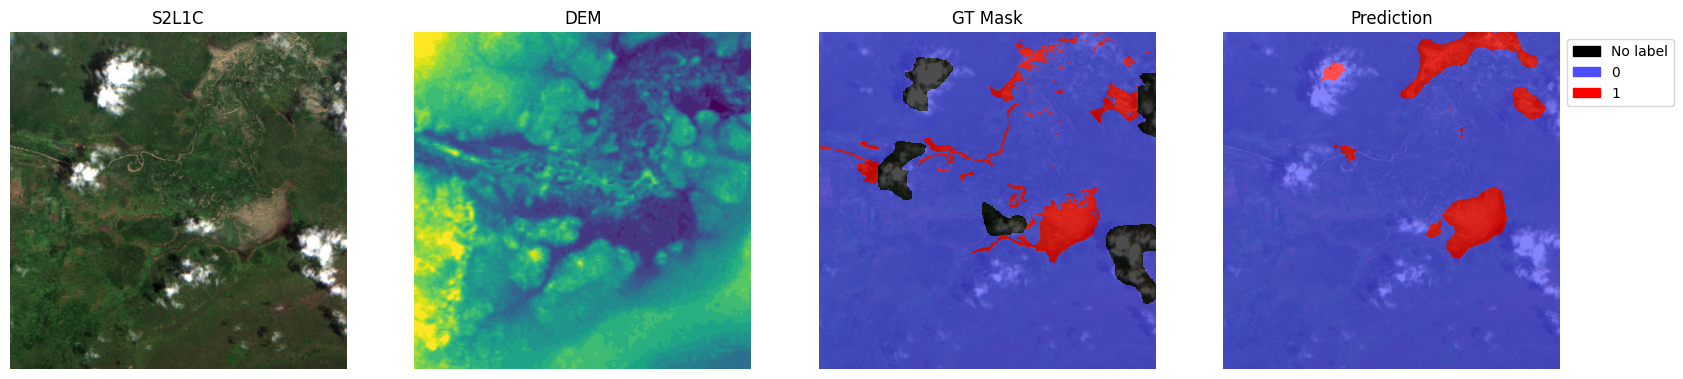

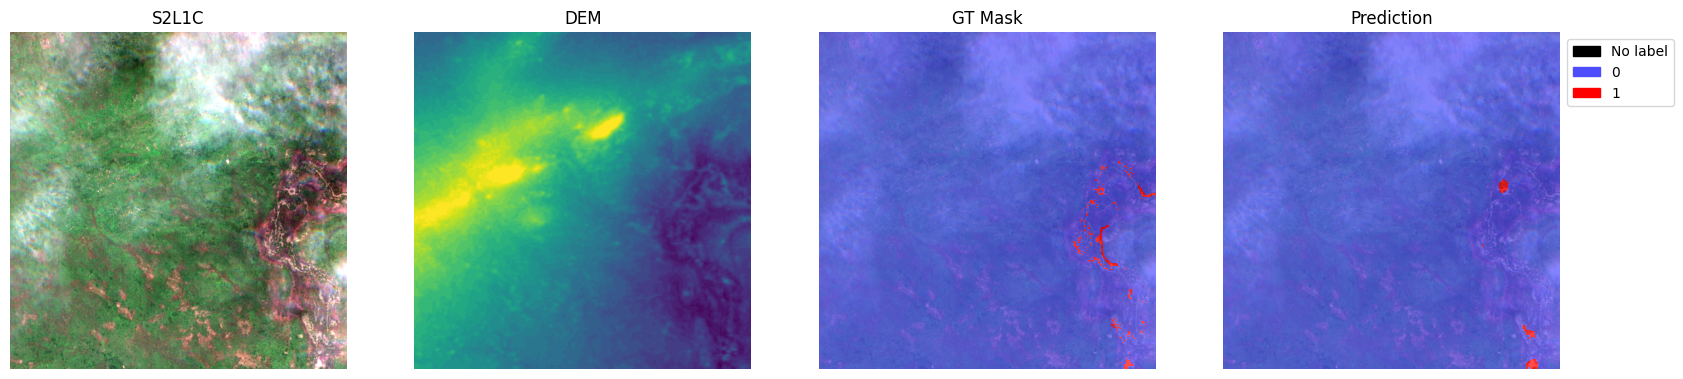

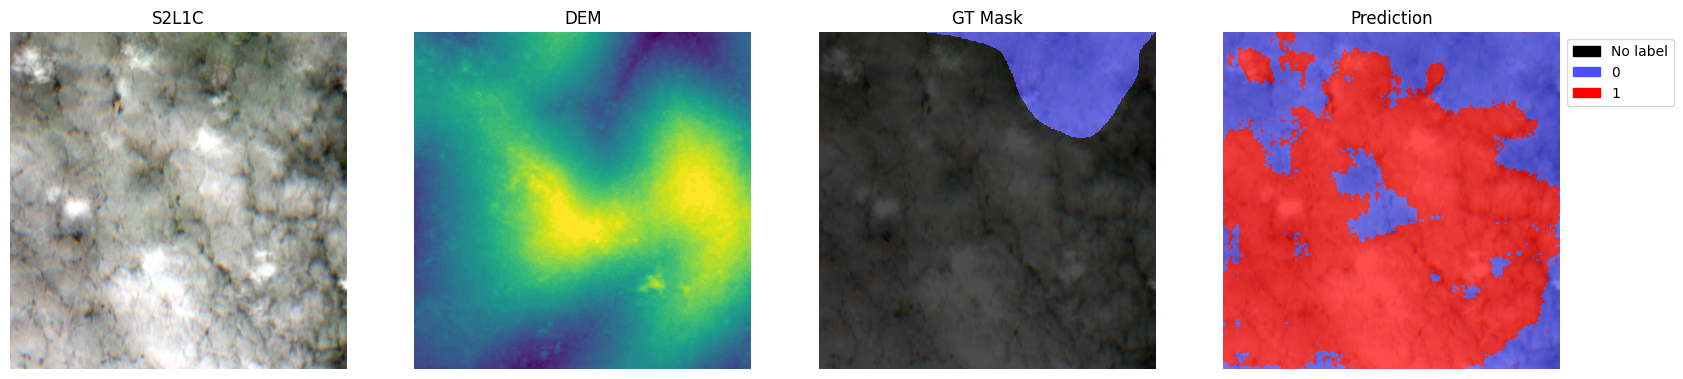

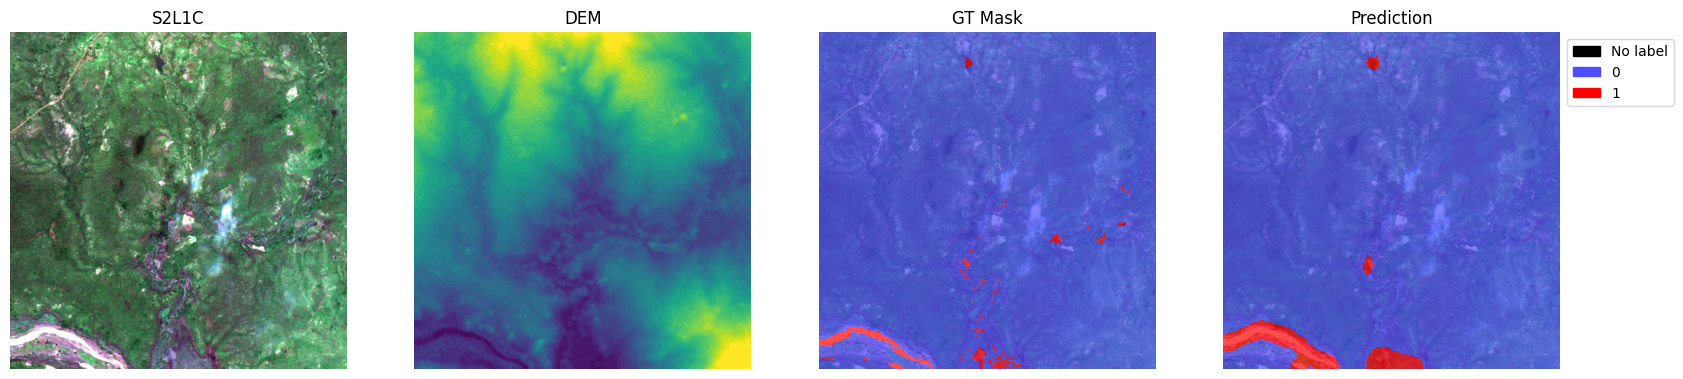

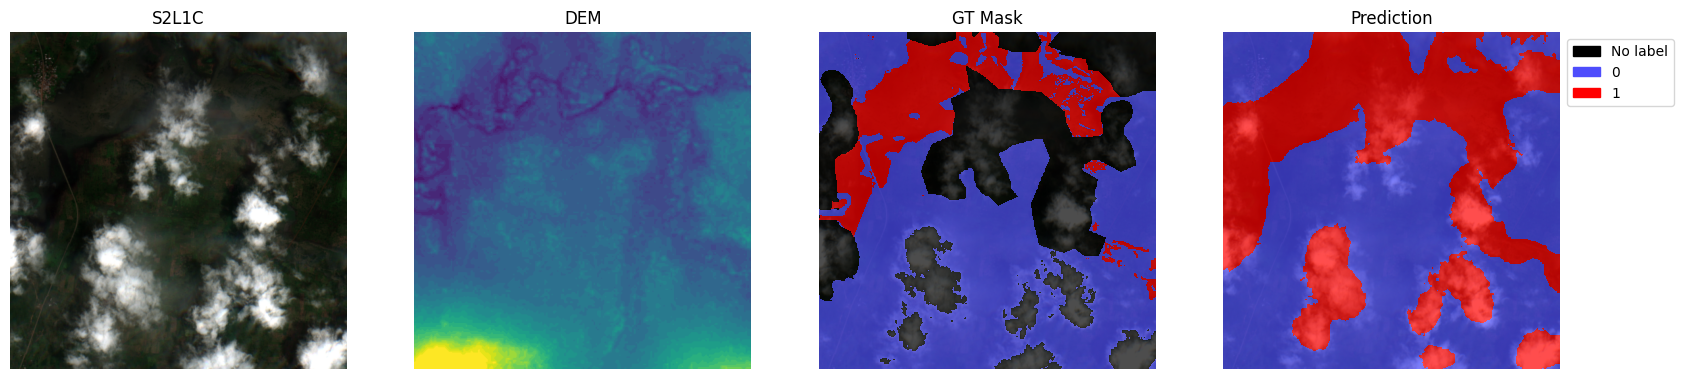

In [17]:
# Now we can use the model for predictions and plotting
model = terratorch.tasks.SemanticSegmentationTask.load_from_checkpoint(
    best_ckpt_path,
    model_factory=model.hparams.model_factory,
    model_args=model.hparams.model_args,
)
model.eval()

test_loader = datamodule.test_dataloader()
with torch.no_grad():
    batch = next(iter(test_loader))
    image = batch["image"].copy()
    batch = datamodule.aug(batch)
    input = batch["image"]
    for mod, value in input.items():
        input[mod] = value.to(model.device)
    masks = batch["mask"].numpy()

    with torch.no_grad():
        outputs = model(input)

    preds = torch.argmax(outputs.output, dim=1).cpu().numpy()

for i in range(5):
    sample = {
        "S2L1C": image["S2L1C"][i].cpu(),
        "DEM": image["DEM"][i].cpu(),
        "mask": batch["mask"][i],
        "prediction": preds[i],
    }
    test_dataset.plot(sample)
    plt.show()

# Note: This demo only trains for 5 epochs by default, which does not result in good predictions.

In [18]:
preds.mean((1, 2))

array([0.06361771, 0.00232697, 0.69265366, 0.0308609 , 0.42488098,
       0.93932724, 0.02017975, 0.        ])

In [25]:
import os, sys
sys.path.append("/Users/ktd/phd/projects/eo/fixlip")
import shapiq 
import src
i = 1
batch = next(iter(test_loader))
image = batch["image"].copy()
batch = datamodule.aug(batch)
input = batch["image"].copy()
for mod, value in input.items():
    input[mod] = value[[i]].to(model.device)
masks = batch["mask"].numpy()

with torch.no_grad():
    game = src.game_terramind.VisionLanguageGame(
        model=model,
        inputs={'S2L1C': input['S2L1C'], 'DEM': input['DEM']}, 
        modalities={'S2L1C': 'image', 'DEM': 'image'}, 
        mask_names={'S2L1C': 'untok_sen2l1c@224', 'DEM': 'untok_dem@224'},
        means={
          # "S2L1C": [2357.089, 2137.385, 2018.788, 2082.986, 2295.651, 2854.537, 3122.849, 3040.560, 3306.481, 1473.847, 506.070, 2472.825, 1838.929],
          # "S2L1C": [0.0] * 13,
          "S2L1C": [-0.5926, -0.6010, -0.5877, -0.7004, -0.5992, -0.1904, -0.0198, -0.1134,
            0.0782, -1.0803, -1.1030, -0.5036, -0.8859],
          # "DEM": [670.665],
          "DEM": [-0.6020],
        },
        batch_size=16,
        grid_step=128,
        aggregation_func=lambda x: torch.argmax(x.output, dim=1).float().mean((1, 2)).cpu()
    )

    n_players_image = game.n_players_image
    # n_players_text = game.n_players_text

    game.empty_value, game.full_value
    fixlip = src.fixlip.FIxLIP(
        n_players_modalities=game.n_players_image, 
        max_order=2,
        p=0.5, # weight
        mode="banzhaf",
        random_state=0
    )

    src.utils.set_seed(0)
    interaction_values = fixlip.approximate_crossmodal(game, budget=2**9)
print(interaction_values)
from plotting_utils import s2_to_rgb, plot_s2, lulc_to_rgb, s1_to_rgb, plot_s1


100%|██████████| 4/4 [00:44<00:00, 11.24s/it]

InteractionValues(
    index=FWBII, max_order=2, min_order=0, estimated=True, estimation_budget=529,
    n_players=32, baseline_value=0.000261338435808731,
    Top 10 interactions:
        (11, 22): 0.0011013242366652062
        (11, 16): 0.001023197035832214
        (11, 18): 0.000834541980328604
        (15, 18): -0.0008176037813724794
        (15, 22): -0.0008382698529324833
        (15, 31): -0.0010505459298508681
        (11, 17): -0.001084921928476846
        (7, 23): -0.0013905204698013431
        (11, 27): -0.001738921680559438
        (11, 26): -0.0024184349178637257
)


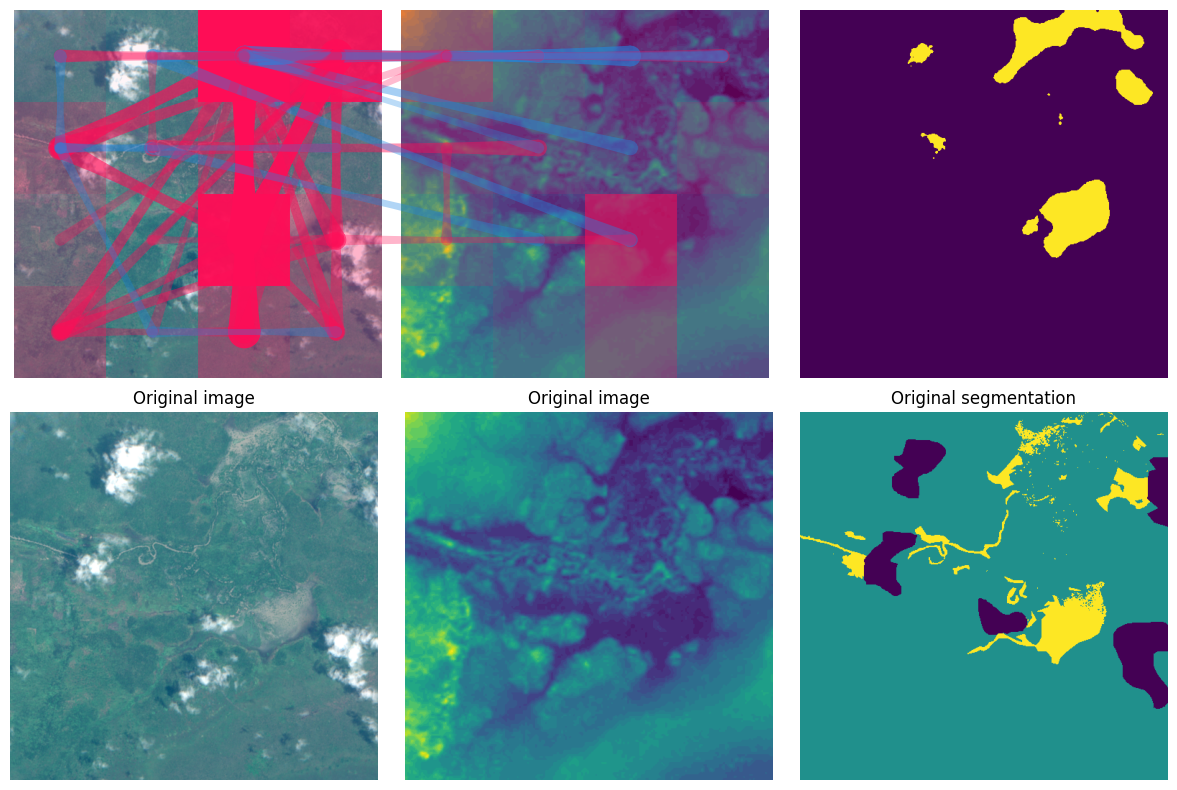

In [24]:
orig = {'S2L1C': input['S2L1C'], 'DEM': input['DEM']}


fig, axs = plt.subplot_mosaic([['a)', 'a)', 'b)'], ['c)', 'd)', 'e)']],
                              layout='constrained',
                              figsize=(12, 8))

_, _, _ = src.plot.plot_image_and_image_together(
    img={'S2L1C': s2_to_rgb(image['S2L1C']), 'DEM': orig['DEM'].cpu().numpy()[0][0]},
    image_players=n_players_image,
    iv=interaction_values,
    plot_interactions=True,
    top_k=50,
    normalize_jointly=True,
    figsize=(8, 8),
    plot_heatmap=True,
    show=False,
    max_value=None,
    image_span=0.95,
    ax=axs['a)']
)

for k, ax in axs.items():
    ax.axis('off')

out = torch.argmax(model(orig).output , dim=1)[0].cpu().numpy()
axs['b)'].imshow(out)

plot_s2(image['S2L1C'][0], ax=axs['c)'])
axs['c)'].set_title("Original image")

axs['d)'].imshow(orig['DEM'].cpu().numpy()[0, 0])
axs['d)'].set_title("Original image")

axs['e)'].imshow(test_dataset[i]['mask'].cpu().numpy())
axs['e)'].set_title("Original segmentation")

plt.tight_layout()
plt.show()

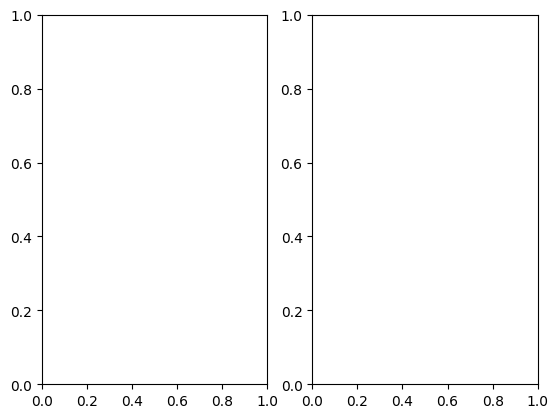

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2)

# Get positions in figure coordinates
p1 = ax1.get_position()
p2 = ax2.get_position()

# Bounding box covering both axes
left   = min(p1.x0, p2.x0)
bottom = min(p1.y0, p2.y0)
right  = max(p1.x1, p2.x1)
top    = max(p1.y1, p2.y1)

overlay = fig.add_axes([left, bottom, right-left, top-bottom],
                       frameon=False)
overlay.set_xticks([])
overlay.set_yticks([])
overlay.patch.set_alpha(0)

IndexError: index 1 is out of bounds for dimension 0 with size 1

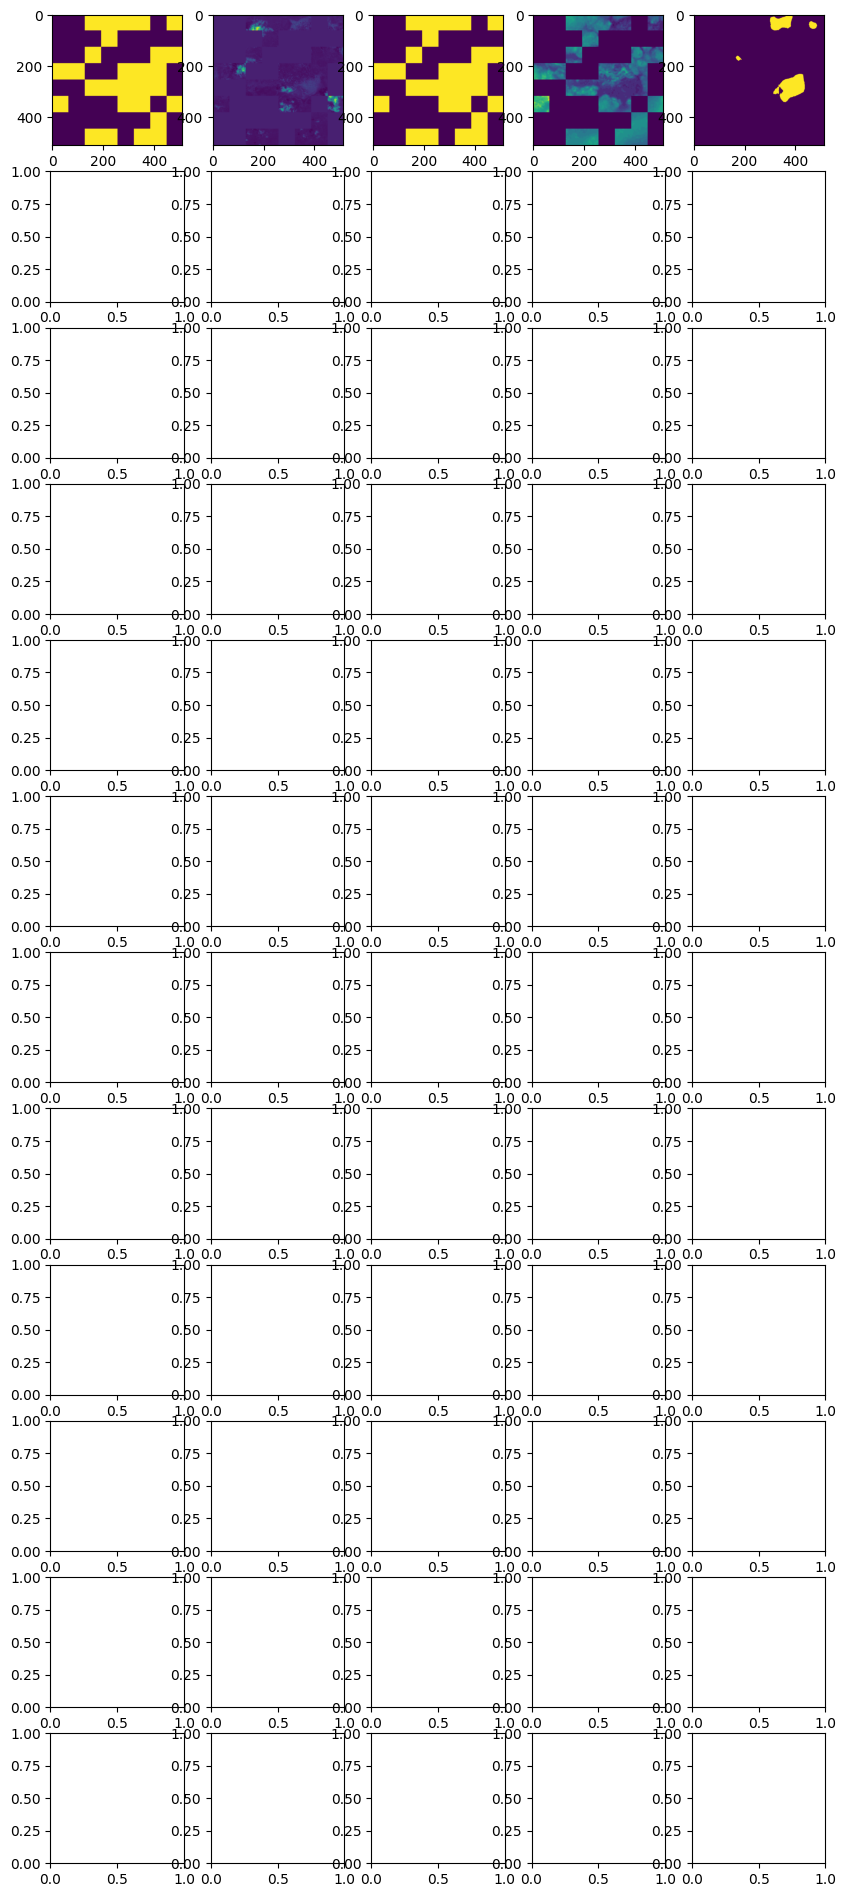

In [22]:
b = 7
fig, axs = plt.subplots(12, 5, figsize=(10, 24))
for i in range(12):
    axs[i, 0].imshow(game.dev['untok_sen2l1c@224']['mask'][i, 0].cpu().numpy())
    axs[i, 1].imshow(game.dev['untok_sen2l1c@224']['input'][i, 1].cpu().numpy())
    axs[i, 2].imshow(game.dev['untok_dem@224']['mask'][i, 0].cpu().numpy())
    axs[i, 3].imshow(game.dev['untok_dem@224']['input'][i, 0].cpu().numpy())
    axs[i, 4].imshow(torch.argmax(game.dev['out'].output, dim=1)[i].cpu())
plt.show()

In [ ]:
from copy import deepcopy
model = terratorch.tasks.SemanticSegmentationTask.load_from_checkpoint(
    best_ckpt_path,
    model_factory=model.hparams.model_factory,
    model_args=model.hparams.model_args,
)
model.eval()


2026-07-22 21:37:04,355 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-small/resolve/main/TerraMind_v1_small.pt "HTTP/1.1 302 Found"


SemanticSegmentationTask(
  (model): PixelWiseModel(
    (encoder): TerraMindViT(
      (encoder_embeddings): ModuleDict(
        (untok_sen2l1c@224): ImageEncoderEmbedding(
          (proj): Linear(in_features=3328, out_features=384, bias=False)
        )
        (untok_dem@224): ImageEncoderEmbedding(
          (proj): Linear(in_features=256, out_features=384, bias=False)
        )
      )
      (encoder): ModuleList(
        (0-11): 12 x Block(
          (norm1): LayerNorm()
          (attn): Attention(
            (qkv): Linear(in_features=384, out_features=1152, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=384, out_features=384, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (drop_path): Identity()
          (norm2): LayerNorm()
          (mlp): Mlp(
            (fc1): Linear(in_features=384, out_features=1536, bias=True)
            (act): GELU(approximate='none')
            (fc2

In [ ]:
test_loader = datamodule.test_dataloader()
with torch.no_grad():
    batch = next(iter(test_loader))
    image = batch["image"].copy()
    batch = datamodule.aug(batch)
    input = batch["image"]
    for mod, value in input.items():
        input[mod] = value.to(model.device)
    masks = batch["mask"].numpy()

    with torch.no_grad():
        outputs = model(input)

    preds = torch.argmax(outputs.output, dim=1).cpu().numpy()

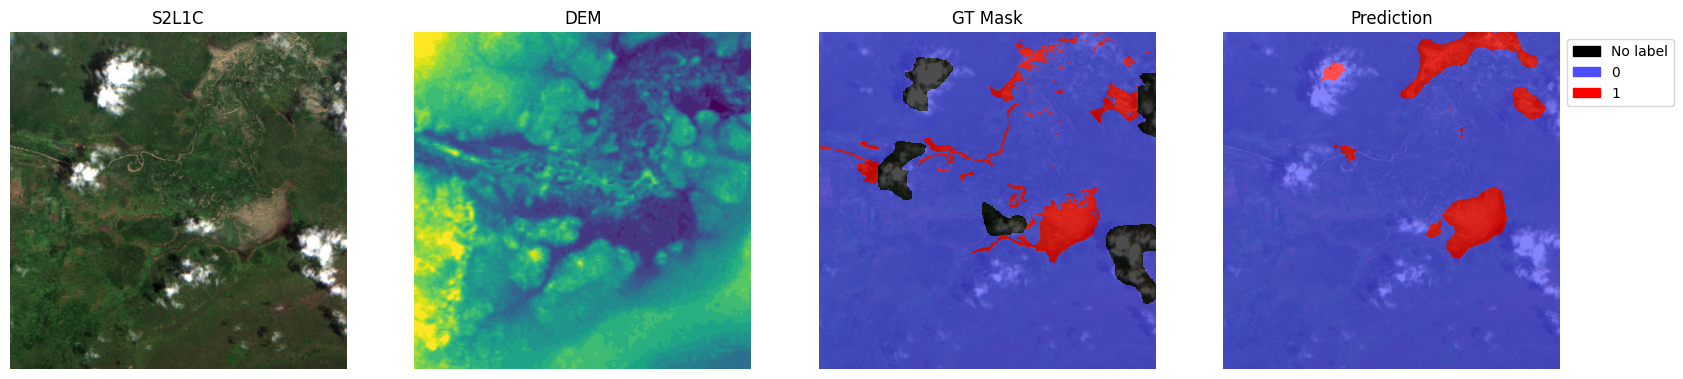

In [ ]:

for i in range(1):
    sample = {
        "S2L1C": image["S2L1C"][i].cpu(),
        "DEM": image["DEM"][i].cpu(),
        "mask": batch["mask"][i],
        "prediction": preds[i],
    }
    test_dataset.plot(sample)
    plt.show()

2026-07-22 21:37:22,854 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-small/resolve/main/TerraMind_v1_small.pt "HTTP/1.1 302 Found"


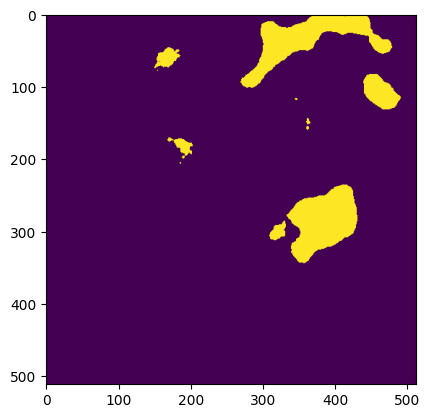

In [ ]:
model = terratorch.tasks.SemanticSegmentationTask.load_from_checkpoint(
    best_ckpt_path,
    model_factory=model.hparams.model_factory,
    model_args=model.hparams.model_args,
)
model.eval()

test_loader = datamodule.test_dataloader()
with torch.no_grad():
    batch = next(iter(test_loader))
    image = batch["image"].copy()
    batch = datamodule.aug(batch)
    input = batch["image"]
    for mod, value in input.items():
        input[mod] = value.to(model.device)
    masks = batch["mask"].numpy()

    with torch.no_grad():
        outputs = model(input)

    preds = torch.argmax(outputs.output, dim=1).cpu().numpy()
plt.imshow(preds[0])

In [ ]:
out

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(512, 512))

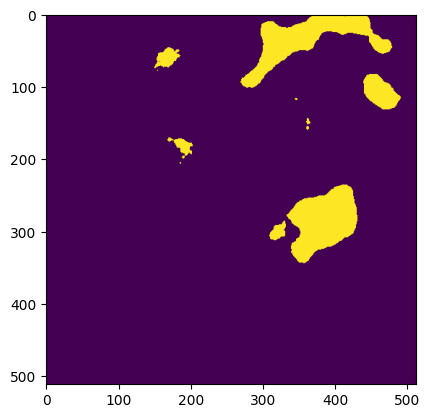

In [ ]:
with torch.no_grad():
    outputs = model(input)

preds = torch.argmax(outputs.output, dim=1).cpu().numpy()
plt.imshow(preds[0])

In [ ]:
input['DEM'].shape

torch.Size([8, 1, 512, 512])